In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    set_feature_names,
    add_degree_feature,
    add_neighborhood_summary_features,
    add_two_hop_summary_features,
    add_feature_interactions,
)
from wildfire_gnn.data.graph_splitters import attach_masks_from_split_file, print_mask_summary

In [3]:
CONFIG_PATH = "configs/gnn_config_gat_uncertainty.yaml"
config = load_yaml_config(CONFIG_PATH)
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

data = set_feature_names(data, config["data"]["raw_feature_names"])

data.y_raw = data.y.clone()

if config["data"].get("target_transform", "none") == "log1p":
    data.y = torch.log1p(data.y)

if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_min=("min" in aggs),
        add_residual=("residual" in aggs),
        add_contrast=("contrast" in aggs),
    )

if config["feature_engineering"].get("add_two_hop_features", False):
    aggs2 = set(config["feature_engineering"].get("two_hop_aggs", []))
    data = add_two_hop_summary_features(
        data,
        add_mean=("mean" in aggs2),
        add_std=("std" in aggs2),
    )

if config["feature_engineering"].get("add_feature_interactions", False):
    data = add_feature_interactions(
        data,
        config["feature_engineering"]["interaction_pairs"]
    )

print_mask_summary(data)
print("x shape:", data.x.shape)

Mask summary:
train: 199167
val  : 40718
test : 60115
total: 300000
nodes: 300000
x shape: torch.Size([300000, 171])


In [4]:
train_outputs = pipeline.train(data, stage="stage2")
train_outputs.history.tail()

,epoch,train_loss,val_loss
75,76,-2.141866,-2.339553
76,77,-2.192150,-2.364455
77,78,-2.262253,-2.528214
78,79,-2.342476,-2.708999
79,80,-2.368202,-2.801595


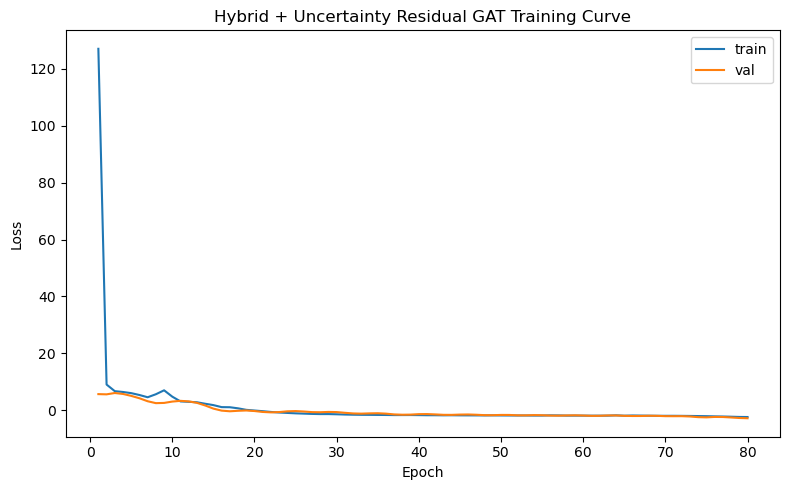

In [5]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hybrid + Uncertainty Residual GAT Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/gat_uncertainty_loss_curve.png", dpi=200)
plt.show()

In [6]:
metrics = pipeline.evaluate(
    data=data,
    checkpoint_path=train_outputs.best_model_path,
    stage="stage2",
)
metrics

{'rmse': 0.030351891879463272,
 'mae': 0.02769353985786438,
 'r2': -2.8434739112854004,
 'pearson': 0.26948821544647217,
 'spearman': 0.41523741850828605,
 'regression_ece': 0.05578123777150453}

In [7]:
pred_df = pd.read_csv(config["paths"]["predictions_table_path"])
pred_df.head()

,y_true,y_pred,uncertainty
0,0.023607,0.047570,0.075264
1,0.030925,0.051974,0.129197
2,0.062656,0.059063,0.128173
3,0.003133,0.041075,0.052083
4,0.002632,0.039430,0.102778


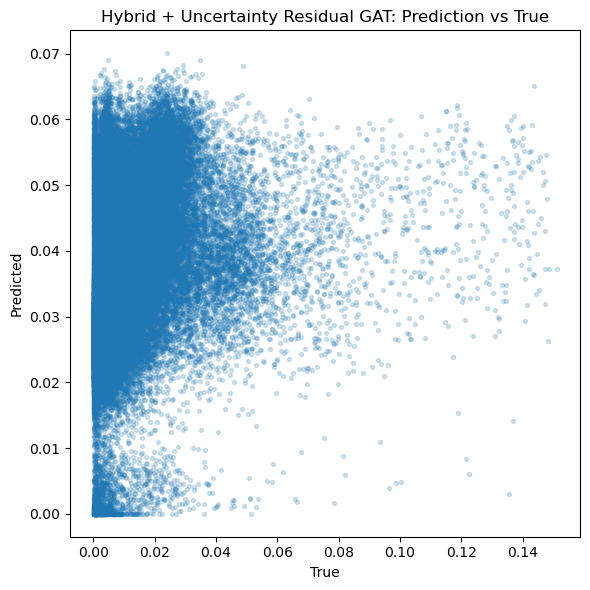

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], alpha=0.2, s=8)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Hybrid + Uncertainty Residual GAT: Prediction vs True")
plt.tight_layout()
plt.savefig("reports/figures/gat_uncertainty_pred_vs_true.png", dpi=200)
plt.show()

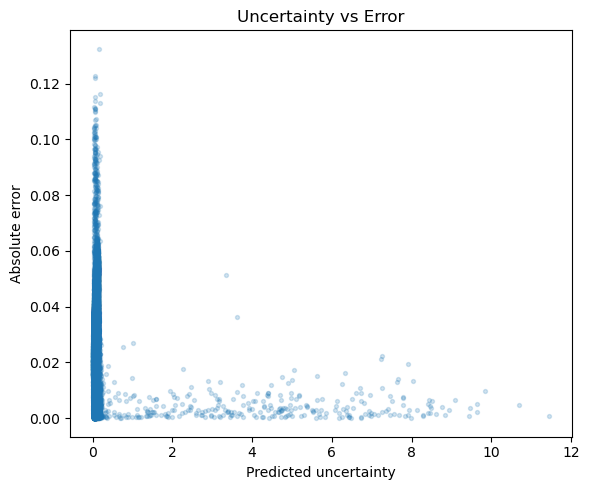

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(pred_df["uncertainty"], np.abs(pred_df["y_true"] - pred_df["y_pred"]), alpha=0.2, s=8)
plt.xlabel("Predicted uncertainty")
plt.ylabel("Absolute error")
plt.title("Uncertainty vs Error")
plt.tight_layout()
plt.savefig("reports/figures/gat_uncertainty_vs_error.png", dpi=200)
plt.show()

In [10]:
bin_df = pd.read_csv(config["paths"]["bin_metrics_table_path"])
bin_df

,rmse,mae,r2,pearson,spearman,bin_low,bin_high,count
0,0.032380,0.030460,-130.904327,0.235616,0.280538,0.00,0.01,37982
1,0.024693,0.021994,-6.144914,0.099281,0.162395,0.01,0.05,20513
2,0.029861,0.025537,-4.380314,0.054605,0.060683,0.05,0.10,1329
3,0.080049,0.078255,-31.939087,0.069732,0.078890,0.10,0.25,291


In [11]:
cal_path = config["paths"]["calibration_metrics_table_path"]
cal_df = pd.read_csv(cal_path) if os.path.exists(cal_path) else pd.DataFrame()
cal_df

,regression_ece
0,0.055781
